## Baseline : Random forest trained on ACLED dataset only

In [10]:
import os
import sys
import pandas as pd
import geopandas as gpd
import numpy as np

PROJECT_ROOT = r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\forecast_model"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\forecast_model")
print(os.getcwd())

from config import settings
from utils import data_cleaning, map_admin_regions
from utils.preprocessing import filter_admin1_data
from models.simple_model import train_and_evaluate_model

C:\Users\Rosa Daneshmandnia\predicting-global-conflict\forecast_model


In [5]:
raw_path = r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\raw\1997-01-01-2025-07-03.csv"
shp_path = r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\raw\boundaries\ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"

df = pd.read_csv(raw_path)
df = df[df["year"] >= 2018].copy()
df["date"] = pd.to_datetime(df["event_date"], format="%d %B %Y")
df["month_year"] = df["date"].dt.to_period("M").dt.to_timestamp()

gdf = gpd.read_file(shp_path)

if "country_code" not in df.columns:
    df["country_code"] = df["country"]

if "admin1" not in df.columns:
    if "admin1_name" in df.columns:
        df["admin1"] = df["admin1_name"]
    elif "admin1_region" in df.columns:
        df["admin1"] = df["admin1_region"]

df_neighbours = map_admin_regions.add_admin1_neighbors(df, gdf)
df_neighbours = df_neighbours[df_neighbours["matched_admin1_id"].notna()].copy()

neighbour_data = data_cleaning.summarise_neighbour_events(df_neighbours)
event_data = data_cleaning.get_monthly_events(df_neighbours)
subevent_data = data_cleaning.get_monthly_subevents(
    df_neighbours,
    ["Excessive force against protesters", "Agreement"]
)

combined = pd.concat([event_data, subevent_data], axis=1).join(neighbour_data, how="left")
combined = data_cleaning.add_lagged_columns(combined)
combined = data_cleaning.add_time_trend_features(combined)
combined = data_cleaning.add_importance_weights(combined)

acled_only_predictors = [
    "Battles (t-1)",
    "Explosions/Remote violence (t-1)",
    "Protests (t-1)",
    "Riots (t-1)",
    "Strategic developments (t-1)",
    "Violence against civilians (t-1)",
    "Excessive force against protesters (t-1)",
    "Agreement (t-1)",
    "Explosions/Remote violence_neighbours (t-1)",
    "Strategic developments_neighbours (t-1)",
    "Protests_neighbours (t-1)",
    "Violence against civilians_neighbours (t-1)",
    "Battles_neighbours (t-1)",
    "Riots_neighbours (t-1)",
    "linear_month_trend",
    "year",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
    "quarter_2",
    "quarter_3",
    "quarter_4",
]

acled_only_targets = [
    "Battles",
    "Explosions/Remote violence",
    "Violence against civilians",
]

acled_model_data = combined[acled_only_predictors + acled_only_targets + ["importance_weight"]].copy()
acled_model_data.head()

C:\Users\Rosa Daneshmandnia\predicting-global-conflict\venv\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
Get neighbour counts: 100%|█████████████████████████████████████████████████| 278730/278730 [00:04<00:00, 58608.82it/s]


Battles (t-1)  Explosions/Remote violence (t-1)  \
matched_admin1_id month_year                                                    
ABW - Aruba       2018-01-01            NaN                               NaN   
                  2018-02-01            0.0                               0.0   
                  2018-03-01            0.0                               0.0   
                  2018-04-01            0.0                               0.0   
                  2018-05-01            0.0                               0.0   

                              Protests (t-1)  Riots (t-1)  \
matched_admin1_id month_year                                
ABW - Aruba       2018-01-01             NaN          NaN   
                  2018-02-01             0.0          0.0   
                  2018-03-01             0.0          0.0   
                  2018-04-01             1.0          0.0   
                  2018-05-01             1.0          0.0   

                              Strategic developments (t-1)  \
matched_admin1_id month_year                                 
ABW - Aruba       2018-01-01                           NaN   
                  2018-02-01                           0.0   
                  2018-03-01                           0.0   
                  2018-04-01                           0.0   
                  2018-05-01                           0.0   

                              Violence against civilians (t-1)  \
matched_admin1_id month_year                                     
ABW - Aruba       2018-01-01                               NaN   
                  2018-02-01                               0.0   
                  2018-03-01                               0.0   
                  2018-04-01                               0.0   
                  2018-05-01                               0.0   

                              Excessive force against protesters (t-1)  \
matched_admin1_id month_year                                             
ABW - Aruba       2018-01-01                                       NaN   
                  2018-02-01                                       0.0   
                  2018-03-01                                       0.0   
                  2018-04-01                                       0.0   
                  2018-05-01                                       0.0   

                              Agreement (t-1)  \
matched_admin1_id month_year                    
ABW - Aruba       2018-01-01              NaN   
                  2018-02-01              0.0   
                  2018-03-01              0.0   
                  2018-04-01              0.0   
                  2018-05-01              0.0   

                              Explosions/Remote violence_neighbours (t-1)  \
matched_admin1_id month_year                                                
ABW - Aruba       2018-01-01                                          NaN   
                  2018-02-01                                          0.0   
                  2018-03-01                                          0.0   
                  2018-04-01                                          0.0   
                  2018-05-01                                          0.0   

                              Strategic developments_neighbours (t-1)  ...  \
matched_admin1_id month_year                                           ...   
ABW - Aruba       2018-01-01                                      NaN  ...   
                  2018-02-01                                      0.0  ...   
                  2018-03-01                                      0.0  ...   
                  2018-04-01                                      0.0  ...   
                  2018-05-01                                      0.0  ...   

                              month_10  month_11  month_12  quarter_2  \
matched_admin1_id month_year                                            
ABW - Aruba       2018-01-01     False  

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
from config import settings

def train_and_evaluate_model_baseline(region_data, target_event, region_name=None):
    train_data = region_data.iloc[:-6]
    test_data = region_data.iloc[-6:]

    X_train = train_data[settings.predictors]
    X_test = test_data[settings.predictors]
    y_train = train_data[target_event]
    y_test = test_data[target_event]

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train, sample_weight=train_data["importance_weight"])
    y_pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(
        np.abs((y_test[y_test != 0] - y_pred[y_test != 0]) / y_test[y_test != 0])
    ) * 100

    return mae, mape

In [10]:
old_predictors = settings.predictors.copy()
settings.predictors = acled_only_predictors

baseline_results = []

for region in acled_model_data.index.get_level_values("matched_admin1_id").unique():
    region_data = filter_admin1_data(acled_model_data, region).sort_index()

    if len(region_data) < 12:
        continue

    for target_event in acled_only_targets:
        train_data = region_data.iloc[:-6]

        if train_data[target_event].nunique() <= 1:
            continue

        mae, mape = train_and_evaluate_model_baseline(
            region_data,
            target_event=target_event,
            region_name=region,
        )

        baseline_results.append({
            "region": region,
            "target": target_event,
            "mae": mae,
            "mape": mape,
        })

settings.predictors = old_predictors

baseline_results_df = pd.DataFrame(baseline_results)

print(f"Rows collected: {len(baseline_results_df)}")
baseline_results_df.head()

Rows collected: 4339


,region,target,mae,mape
0,AFG - Badakhshan,Battles,0.680000,18.875
1,AFG - Badakhshan,Explosions/Remote violence,0.340000,NaN
2,AFG - Badakhshan,Violence against civilians,1.886667,113.870
3,AFG - Badghis,Battles,0.616667,30.375
4,AFG - Badghis,Explosions/Remote violence,1.711667,77.500


In [11]:
baseline_summary = (
    baseline_results_df
    .groupby("target")[["mae", "mape"]]
    .mean()
    .round(3)
)

baseline_summary

,mae,mape
target,,
Battles,1.782,96.301
Explosions/Remote violence,4.319,125.250
Violence against civilians,0.932,79.102


## RAW COUNT PERSISTENCE BASELINE

In [16]:
# predict next month = this month (naive baseline for count prediction)

persistence_rows = []

for region in VALID_REGIONS:
    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    for target in DELTA_TARGETS:
        raw_col = RAW_TARGET_MAP[target]
        y_test = test_data[raw_col]
        y_prev = test_data[raw_col].shift(1).fillna(train_data[raw_col].iloc[-1])

        for actual, pred in zip(y_test.values, y_prev.values):
            persistence_rows.append({
                'region': region,
                'target': target,
                'actual_count': actual,
                'predicted_count': pred,
                'abs_error_count': abs(actual - pred),
                'mape_count': abs(actual - pred) / actual * 100 if actual != 0 else np.nan,
            })

persistence_df = pd.DataFrame(persistence_rows)

persistence_summary = (
    persistence_df
    .groupby('target')
    .agg(
        mae=('abs_error_count', 'mean'),
        mape=('mape_count', 'mean'),
    )
    .round(3)
)

print("Raw count persistence baseline:")
print(persistence_summary)

Raw count persistence baseline:
                         mae    mape
target                              
delta_battles          0.902  91.093
delta_remote_violence  1.119  93.368
delta_vac              0.771  81.444


## Final Model : Two Stage CatBoost
**it includes:** 
1) 2 stage catboost : classifier + regressor 
2) per target lag strategy: for battles 't-1' , for VAC and Remote violance 't-1', 't-6', 't-12'
3) Raw NaN Passthrough : let CATBoost handle it by itslef instead of fillna
4) Native Categorical handling by catboost for religion and income_level
   
**not included:**
1) Target Encoding
2) Holiday memory features: 3 years mean test that we did
3) next_month holiday
4) country hierarchy

In [2]:
import warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostClassifier, CatBoostRegressor

model_data = pd.read_csv(
    r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\processed\model_data.csv"
)
model_data = model_data.set_index(['matched_admin1_id', 'month_year']).sort_index()
print(f"CAST+ data loaded: {model_data.shape[0]:,} rows x {model_data.shape[1]} cols")

CAST+ data loaded: 278,820 rows x 100 cols


In [3]:
RANDOM_STATE = 42
CHANGE_THRESHOLD = 0.50
all_cols = model_data.columns.tolist()

DELTA_TARGETS = ['delta_battles', 'delta_remote_violence', 'delta_vac']

RAW_TARGET_MAP = {
    'delta_battles':        'Battles',
    'delta_remote_violence': 'Explosions/Remote violence',
    'delta_vac':            'Violence against civilians',
}

conflict_lag_features = [c for c in all_cols if c.endswith('(t-1)') and c.split(' (t-1)')[0] in [
    'Battles', 'Explosions/Remote violence', 'Protests', 'Riots',
    'Strategic developments', 'Violence against civilians',
    'Excessive force against protesters', 'Agreement'
]]
neighbor_features    = [c for c in all_cols if '_neighbours (t-1)' in c]
time_features        = [c for c in all_cols if c in ['linear_month_trend', 'year']
                        or c.startswith('month_') or c.startswith('quarter_')]
worldbank_lag_features = [c for c in [
    'inflation (t-1)', 'youth_unemployment (t-1)',
    'income_inequality (t-1)', 'income_level_code'
] if c in all_cols]
religion_features    = [c for c in all_cols if c in [
    'majority_religion', 'majority_pct', 'minority1_religion', 'minority1_pct',
    'minority2_religion', 'minority2_pct', 'nonreligpct'
]]
holiday_current_features     = [c for c in all_cols if 'holiday_count' in c and '(t-1)' not in c]
holiday_interaction_current  = [c for c in all_cols if c in [
    'weighted_holidays_majority', 'weighted_holidays_minority1', 'weighted_holidays_minority2',
    'minority_tension_minority1', 'minority_tension_minority2', 'minority_tension_total',
    'total_religious_mobilization'
]]
wbd_engineered_features = [c for c in all_cols if c in [
    'structural_vulnerability', 'inflation_shock', 'shock_vulnerability',
    'conflict_momentum', 'violence_escalation', 'macro_conflict_pressure'
]]
risk_features = [c for c in all_cols if c.startswith('risk_')]

baseline_feature_cols = list(dict.fromkeys(
    conflict_lag_features + neighbor_features + time_features
    + worldbank_lag_features + religion_features + holiday_current_features
    + holiday_interaction_current + wbd_engineered_features + risk_features
))

# Compute t-6 and t-12 lags
CONFLICT_COLS_TO_LAG = [
    'Battles', 'Explosions/Remote violence', 'Protests', 'Riots',
    'Strategic developments', 'Violence against civilians',
    'Excessive force against protesters', 'Agreement'
]
RISK_COLS_TO_LAG = [
    'risk_contested_election', 'risk_crop_failure', 'risk_economic_concern',
    'risk_ethnic_tension', 'risk_military_coup', 'risk_natural_disaster',
    'risk_political_assassination'
]
for lag in [6, 12]:
    for col in CONFLICT_COLS_TO_LAG + RISK_COLS_TO_LAG:
        if col not in model_data.columns:
            continue
        new_col = f'{col} (t-{lag})'
        if new_col not in model_data.columns:
            model_data[new_col] = model_data.groupby(
                level='matched_admin1_id')[col].shift(lag)

extended_feature_cols = list(dict.fromkeys(
    conflict_lag_features
    + [f'{c} (t-6)'  for c in CONFLICT_COLS_TO_LAG if f'{c} (t-6)'  in model_data.columns]
    + [f'{c} (t-12)' for c in CONFLICT_COLS_TO_LAG if f'{c} (t-12)' in model_data.columns]
    + neighbor_features + time_features + worldbank_lag_features
    + religion_features + holiday_current_features + holiday_interaction_current
    + wbd_engineered_features
    + risk_features
    + [f'{c} (t-6)'  for c in RISK_COLS_TO_LAG if f'{c} (t-6)'  in model_data.columns]
    + [f'{c} (t-12)' for c in RISK_COLS_TO_LAG if f'{c} (t-12)' in model_data.columns]
))

per_target_feature_cols = {
    'delta_battles':         baseline_feature_cols,
    'delta_remote_violence': extended_feature_cols,
    'delta_vac':             extended_feature_cols,
}

print(f"Baseline features:  {len(baseline_feature_cols)}")
print(f"Extended features:  {len(extended_feature_cols)}")

Baseline features:  76
Extended features:  96


In [7]:
# Compute delta targets
for delta_col, raw_col in RAW_TARGET_MAP.items():
    if delta_col not in model_data.columns:
        model_data[delta_col] = (
            model_data.groupby(level='matched_admin1_id')[raw_col].diff()
        )

print("Delta targets ready:")
for col in DELTA_TARGETS:
    print(f"  {col}: {model_data[col].notna().sum()} non-null rows")

def split_region_data(region_data, test_horizon=6):
    return region_data.iloc[:-test_horizon], region_data.iloc[-test_horizon:]

def prepare_catboost_inputs(train_df, test_df, feature_cols):
    cat_cols = train_df[feature_cols].select_dtypes(
        include=['object', 'category']
    ).columns.tolist()
    if 'income_level_code (t-1)' in feature_cols and \
       'income_level_code (t-1)' not in cat_cols:
        cat_cols.append('income_level_code (t-1)')
    X_train = train_df[feature_cols].copy()
    X_test  = test_df[feature_cols].copy()
    for col in cat_cols:
        X_train[col] = X_train[col].astype(str).fillna('missing')
        X_test[col]  = X_test[col].astype(str).fillna('missing')
    return X_train, X_test, cat_cols

VALID_REGIONS = []
for region in model_data.index.get_level_values('matched_admin1_id').unique():
    region_data = model_data.loc[region].sort_index()
    if len(region_data) < 12:
        continue
    train_data, _ = split_region_data(region_data)
    if train_data[DELTA_TARGETS].nunique().max() <= 1:
        continue
    VALID_REGIONS.append(region)

print(f"Valid regions: {len(VALID_REGIONS)}")

Delta targets ready:
  delta_battles: 275633 non-null rows
  delta_remote_violence: 275633 non-null rows
  delta_vac: 275633 non-null rows
Valid regions: 2205


In [12]:
import gc

def run_two_stage(regions, feat_col_map, label='', collect_fi=True):
    rows = []
    fi_records = []

    for i, region in enumerate(regions, start=1):
        if i % 200 == 0:
            print(f"{label}: {i}/{len(regions)} regions")
        if i % 100 == 0:
            gc.collect()

        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] \
            if 'importance_weight' in train_data.columns else None

        for target in DELTA_TARGETS:
            feat_cols  = feat_col_map[target]
            train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
            test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

            if len(train_pair) == 0 or len(test_pair) == 0:
                continue

            y_train = train_pair[target]
            y_test  = test_pair[target]
            y_bin   = (y_train != 0).astype(int)

            if y_bin.nunique() <= 1:
                continue

            weights = weights_full.loc[train_pair.index] \
                if weights_full is not None else None
            X_train, X_test, cat_cols = prepare_catboost_inputs(
                train_pair, test_pair, feat_cols
            )

            fit_kw = {}
            if cat_cols: fit_kw['cat_features'] = cat_cols
            if weights is not None: fit_kw['sample_weight'] = weights.values

            clf = CatBoostClassifier(
                iterations=300, learning_rate=0.05, depth=4,
                random_seed=RANDOM_STATE, verbose=0
            )
            clf.fit(X_train, y_bin, **fit_kw)
            change_flag = (
                clf.predict_proba(X_test)[:, 1] >= CHANGE_THRESHOLD
            ).astype(int)

            if collect_fi:
                fi_records.append(pd.DataFrame({
                    'stage':     'Stage 1 - classifier',
                    'target':    target,
                    'region':    region,
                    'feature':   feat_cols,
                    'importance': clf.feature_importances_,
                }))

            nonzero_mask = y_train != 0
            if nonzero_mask.sum() < 5:
                stage2_pred = np.zeros(len(y_test))
            else:
                reg = CatBoostRegressor(
                    iterations=300, learning_rate=0.05, depth=4,
                    random_seed=RANDOM_STATE, verbose=0
                )
                reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
                if weights is not None:
                    reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
                reg.fit(
                    X_train.loc[nonzero_mask],
                    y_train.loc[nonzero_mask],
                    **reg_kw
                )
                stage2_pred = reg.predict(X_test)

                if collect_fi:
                    fi_records.append(pd.DataFrame({
                        'stage':     'Stage 2 - regressor',
                        'target':    target,
                        'region':    region,
                        'feature':   feat_cols,
                        'importance': reg.feature_importances_,
                    }))

            final_pred = change_flag * stage2_pred

            raw_col = RAW_TARGET_MAP[target]
            y_prev = test_data[raw_col].shift(1).fillna(
                train_data[raw_col].iloc[-1]
            )

            for j, (actual, pred) in enumerate(zip(y_test.values, final_pred)):
                rows.append({
                    'region':            region,
                    'target':            target,
                    'model':             label,
                    'actual_delta':      actual,
                    'pred_delta':        pred,
                    'y_prev':            y_prev.iloc[j],
                    'abs_error_delta':   abs(actual - pred),
                    'correct_direction': int(
                        (actual == 0 and pred == 0) or
                        (actual > 0 and pred > 0) or
                        (actual < 0 and pred < 0)
                    ),
                })

    results_df = pd.DataFrame(rows)
    fi_df = pd.concat(fi_records, ignore_index=True) \
        if fi_records else pd.DataFrame()

    # Save everything immediately
    results_df.to_csv(f'{label}_results.csv', index=False)
    if collect_fi:
        fi_df.to_csv(f'{label}_fi.csv', index=False)
    print(f"Saved {label}_results.csv and {label}_fi.csv")

    return results_df, fi_df

## feature ablation

In [14]:

ablation_configs = {
    'Full model':    per_target_feature_cols,
    'No World Bank': {t: [f for f in per_target_feature_cols[t]
                          if f not in worldbank_lag_features]
                     for t in DELTA_TARGETS},
    'No Religion':   {t: [f for f in per_target_feature_cols[t]
                          if f not in religion_features]
                     for t in DELTA_TARGETS},
    'No Holidays':   {t: [f for f in per_target_feature_cols[t]
                          if f not in holiday_current_features + holiday_interaction_current]
                     for t in DELTA_TARGETS},
    'No Risk':       {t: [f for f in per_target_feature_cols[t]
                          if f not in risk_features]
                     for t in DELTA_TARGETS},
}

ablation_rows = []
for config_name, feat_map in ablation_configs.items():
    print(f"Running: {config_name}")
    results, _ = run_two_stage(VALID_REGIONS[:100], feat_map, label=config_name)
    ablation_rows.append(results)

ablation_df = pd.concat(ablation_rows, ignore_index=True)

ablation_summary = (
    ablation_df
    .groupby(['model', 'target'])['abs_error_delta']
    .mean()
    .reset_index()
    .rename(columns={'abs_error_delta': 'mae', 'model': 'config'})
)

ablation_pivot = ablation_summary.pivot_table(
    index='target', columns='config', values='mae'
).round(4)

for col in [c for c in ablation_pivot.columns if c != 'Full model']:
    ablation_pivot[f'{col} Δ%'] = (
        (ablation_pivot[col] - ablation_pivot['Full model'])
        / ablation_pivot['Full model'] * 100
    ).round(2)

print(ablation_pivot.to_string())

Running: Full model
Saved Full model_results.csv and Full model_fi.csv
Running: No World Bank
Saved No World Bank_results.csv and No World Bank_fi.csv
Running: No Religion
Saved No Religion_results.csv and No Religion_fi.csv
Running: No Holidays
Saved No Holidays_results.csv and No Holidays_fi.csv
Running: No Risk
Saved No Risk_results.csv and No Risk_fi.csv
config                 Full model  No Holidays  No Religion  No Risk  No World Bank  No Holidays Δ%  No Religion Δ%  No Risk Δ%  No World Bank Δ%
target                                                                                                                                           
delta_battles              1.0208       0.9959       1.0208   0.9347         0.9692           -2.44             0.0       -8.43             -5.05
delta_remote_violence      0.3128       0.3128       0.3128   0.3042         0.3149            0.00             0.0       -2.75              0.67
delta_vac                  0.4282       0.4343       0.

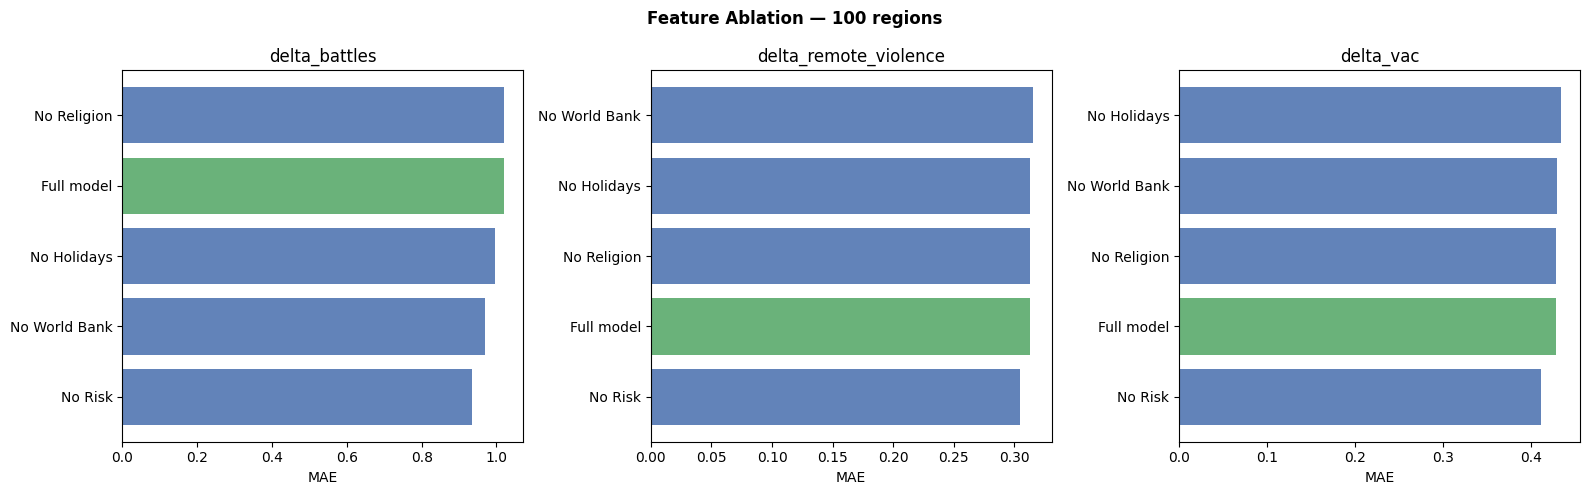

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
import matplotlib.pyplot as plt
import seaborn as sns

for ax, target in zip(axes, DELTA_TARGETS):
    data = ablation_summary[ablation_summary['target'] == target].sort_values('mae')
    colors = ['#55A868' if c == 'Full model' else '#4C72B0' for c in data['config']]
    ax.barh(data['config'], data['mae'], color=colors, alpha=0.88)
    ax.set_title(target)
    ax.set_xlabel('MAE')

plt.suptitle('Feature Ablation — 100 regions', fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
import gc
gc.collect()

print(f"Starting full scale run on {len(VALID_REGIONS)} regions...")
full_results_df, full_fi_df = run_two_stage(
    VALID_REGIONS, per_target_feature_cols, label='CAST+'
)
print(f"Done. Total predictions: {len(full_results_df)}")

Starting full scale run on 2205 regions...
CAST+: 200/2205 regions
CAST+: 400/2205 regions
CAST+: 600/2205 regions
CAST+: 800/2205 regions
CAST+: 1000/2205 regions
CAST+: 1200/2205 regions
CAST+: 1400/2205 regions
CAST+: 1600/2205 regions
CAST+: 1800/2205 regions
CAST+: 2000/2205 regions
CAST+: 2200/2205 regions
Saved CAST+_results.csv and CAST+_fi.csv
Done. Total predictions: 25980


## convert delta predictions to counts

In [21]:
full_results_df['predicted_count'] = (
    full_results_df['y_prev'] + full_results_df['pred_delta']
).clip(lower=0)

full_results_df['actual_count'] = (
    full_results_df['y_prev'] + full_results_df['actual_delta']
)

full_results_df['abs_error_count'] = abs(
    full_results_df['actual_count'] - full_results_df['predicted_count']
)

full_results_df['mape_count'] = np.where(
    full_results_df['actual_count'] != 0,
    abs(full_results_df['actual_count'] - full_results_df['predicted_count'])
    / abs(full_results_df['actual_count']) * 100,
    np.nan
)

print("Count-level errors computed.")

Count-level errors computed.


## final comparison

In [23]:
castplus_summary = (
    full_results_df
    .groupby('target')
    .agg(
        mae=('abs_error_count', 'mean'),
        mape=('mape_count', 'mean'),
        directional_accuracy=('correct_direction', 'mean'),
    )
    .round(3)
)

cast_summary = pd.DataFrame({
    'mae':  [1.782, 4.319, 0.932],
    'mape': [96.301, 125.250, 79.102],
}, index=['delta_battles', 'delta_remote_violence', 'delta_vac'])

final_table = pd.DataFrame({
    'CAST_MAE':           cast_summary['mae'],
    'CAST+_MAE':          castplus_summary['mae'],
    'MAE_improvement_%':  ((cast_summary['mae'] - castplus_summary['mae'])
                           / cast_summary['mae'] * 100).round(2),
    'CAST_MAPE':          cast_summary['mape'],
    'CAST+_MAPE':         castplus_summary['mape'],
    'MAPE_improvement_%': ((cast_summary['mape'] - castplus_summary['mape'])
                           / cast_summary['mape'] * 100).round(2),
    'CAST+_Dir_Acc':      castplus_summary['directional_accuracy'],
})

print("=" * 70)
print("FINAL COMPARISON: CAST Baseline vs CAST+")
print("=" * 70)
print(final_table.to_string())

FINAL COMPARISON: CAST Baseline vs CAST+
                       CAST_MAE  CAST+_MAE  MAE_improvement_%  CAST_MAPE  CAST+_MAPE  MAPE_improvement_%  CAST+_Dir_Acc
delta_battles             1.782      1.384              22.33     96.301      96.145                0.16          0.789
delta_remote_violence     4.319      2.546              41.05    125.250      93.125               25.65          0.816
delta_vac                 0.932      0.836              10.30     79.102      79.295               -0.24          0.790


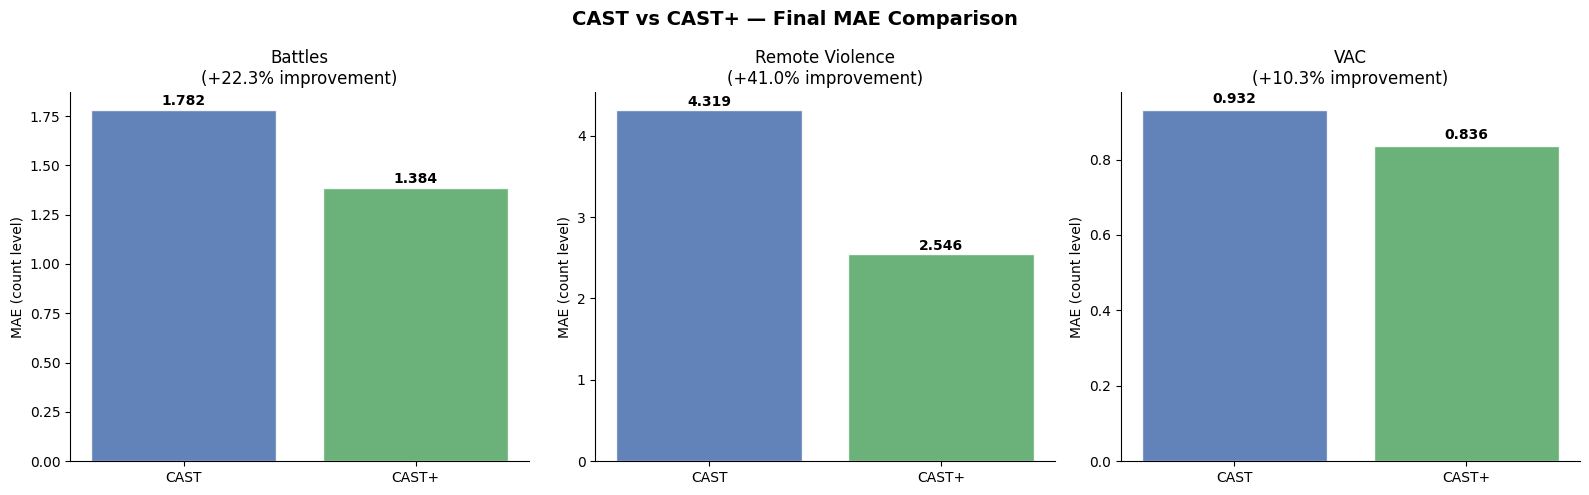

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

targets_clean = {
    'delta_battles':         'Battles',
    'delta_remote_violence': 'Remote Violence',
    'delta_vac':             'VAC'
}

for ax, target in zip(axes, DELTA_TARGETS):
    cast_mae     = final_table.loc[target, 'CAST_MAE']
    castplus_mae = final_table.loc[target, 'CAST+_MAE']
    improvement  = final_table.loc[target, 'MAE_improvement_%']

    bars = ax.bar(
        ['CAST', 'CAST+'],
        [cast_mae, castplus_mae],
        color=['#4C72B0', '#55A868'],
        alpha=0.88, edgecolor='white'
    )
    for bar, val in zip(bars, [cast_mae, castplus_mae]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold'
        )
    ax.set_title(f'{targets_clean[target]}\n({improvement:+.1f}% improvement)')
    ax.set_ylabel('MAE (count level)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('CAST vs CAST+ — Final MAE Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
persistence_overall = persistence_summary['mae'].mean()
cast_overall = cast_summary['mae'].mean()
castplus_overall = final_table['CAST+_MAE'].mean()

progression = pd.DataFrame([
    {
        'Stage': 'CAST Baseline',
        'Model': 'RF (ACLED only)',
        'Battles MAE': cast_summary.loc['delta_battles', 'mae'],
        'Remote Violence MAE': cast_summary.loc['delta_remote_violence', 'mae'],
        'VAC MAE': cast_summary.loc['delta_vac', 'mae'],
        'Overall MAE': round(cast_overall, 3),
        'Δ vs CAST': '—',
    },
    {
        'Stage': 'Persistence',
        'Model': 'Y(t) = Y(t-1)',
        'Battles MAE': persistence_summary.loc['delta_battles', 'mae'],
        'Remote Violence MAE': persistence_summary.loc['delta_remote_violence', 'mae'],
        'VAC MAE': persistence_summary.loc['delta_vac', 'mae'],
        'Overall MAE': round(persistence_overall, 3),
        'Δ vs CAST': f"{((persistence_overall - cast_overall) / cast_overall * 100):.1f}%",
    },
    {
        'Stage': 'CAST+',
        'Model': 'Two-Stage CatBoost',
        'Battles MAE': final_table.loc['delta_battles', 'CAST+_MAE'],
        'Remote Violence MAE': final_table.loc['delta_remote_violence', 'CAST+_MAE'],
        'VAC MAE': final_table.loc['delta_vac', 'CAST+_MAE'],
        'Overall MAE': round(castplus_overall, 3),
        'Δ vs CAST': f"{((castplus_overall - cast_overall) / cast_overall * 100):.1f}%",
    },
])

progression = progression.set_index('Stage')

print("=" * 80)
print("OVERALL PROGRESSION TABLE")
print("=" * 80)
print(progression.to_string())
print(f"\nMean MAE improvement (CAST+ vs CAST): {final_table['MAE_improvement_%'].mean():.1f}%")
print(f"20% target: {'✓ ACHIEVED' if final_table['MAE_improvement_%'].mean() >= 20 else '✗ NOT achieved'}")

OVERALL PROGRESSION TABLE
                            Model  Battles MAE  Remote Violence MAE  VAC MAE  Overall MAE Δ vs CAST
Stage                                                                                              
CAST Baseline     RF (ACLED only)        1.782                4.319    0.932        2.344         —
Persistence         Y(t) = Y(t-1)        0.902                1.119    0.771        0.931    -60.3%
CAST+          Two-Stage CatBoost        1.384                2.546    0.836        1.589    -32.2%

Mean MAE improvement (CAST+ vs CAST): 24.6%
20% target: ✓ ACHIEVED


In [26]:
# Directional accuracy summary
dir_acc_table = pd.DataFrame({
    'CAST+ Directional Accuracy': [
        final_table.loc['delta_battles', 'CAST+_Dir_Acc'],
        final_table.loc['delta_remote_violence', 'CAST+_Dir_Acc'],
        final_table.loc['delta_vac', 'CAST+_Dir_Acc'],
    ],
}, index=['Battles', 'Remote Violence', 'VAC'])

dir_acc_table['Interpretation'] = [
    f"{v*100:.1f}% of months correctly classified as escalating/de-escalating/stable"
    for v in dir_acc_table['CAST+ Directional Accuracy']
]

print(dir_acc_table.to_string())

                 CAST+ Directional Accuracy                                                           Interpretation
Battles                               0.789  78.9% of months correctly classified as escalating/de-escalating/stable
Remote Violence                       0.816  81.6% of months correctly classified as escalating/de-escalating/stable
VAC                                   0.790  79.0% of months correctly classified as escalating/de-escalating/stable


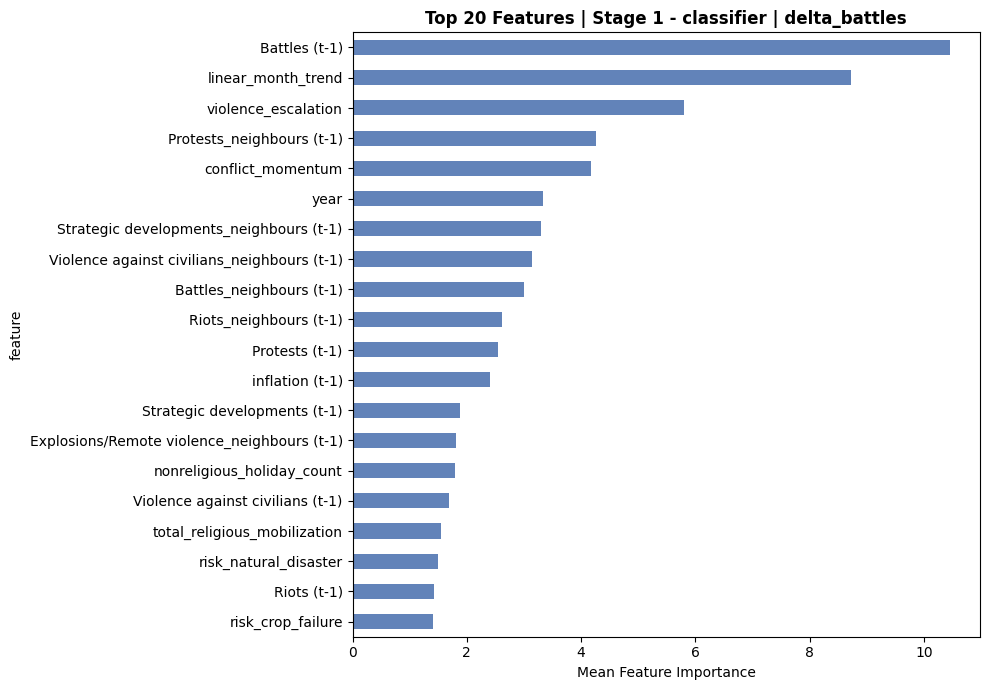

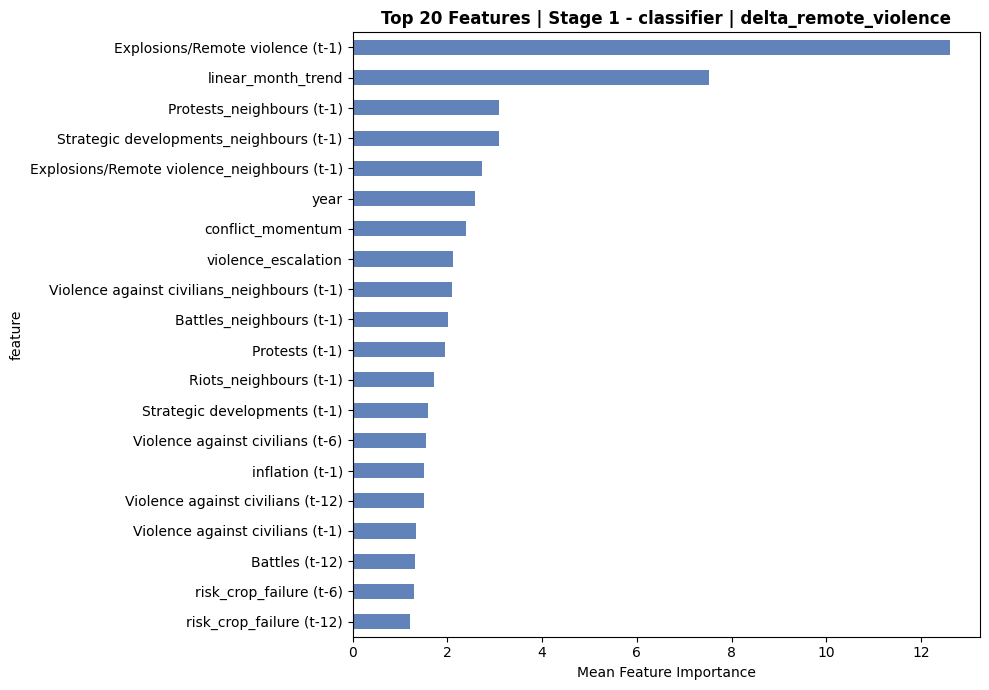

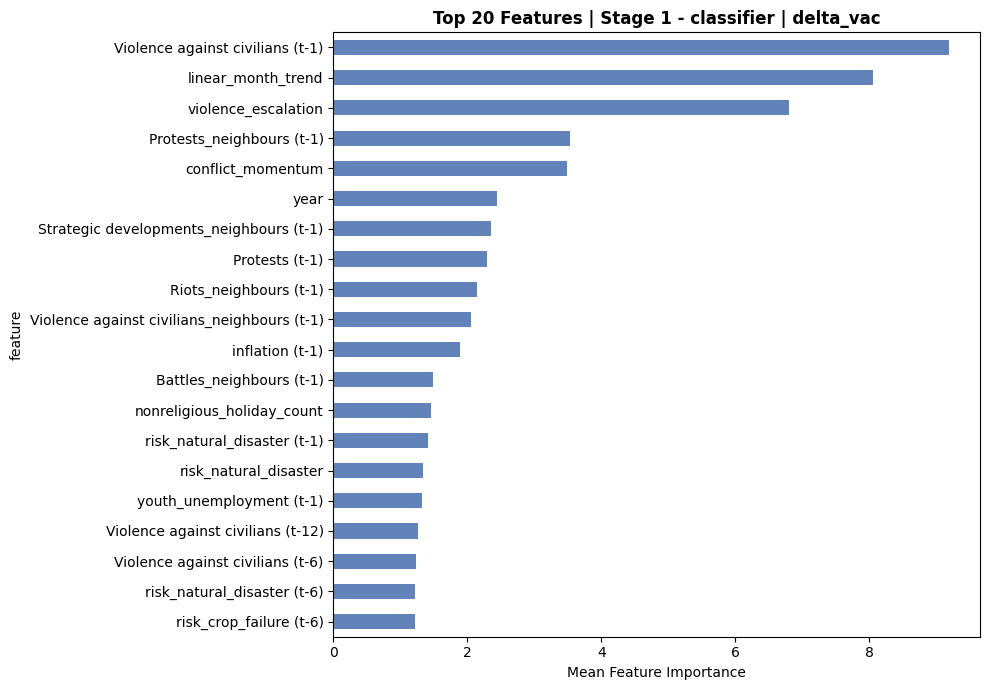

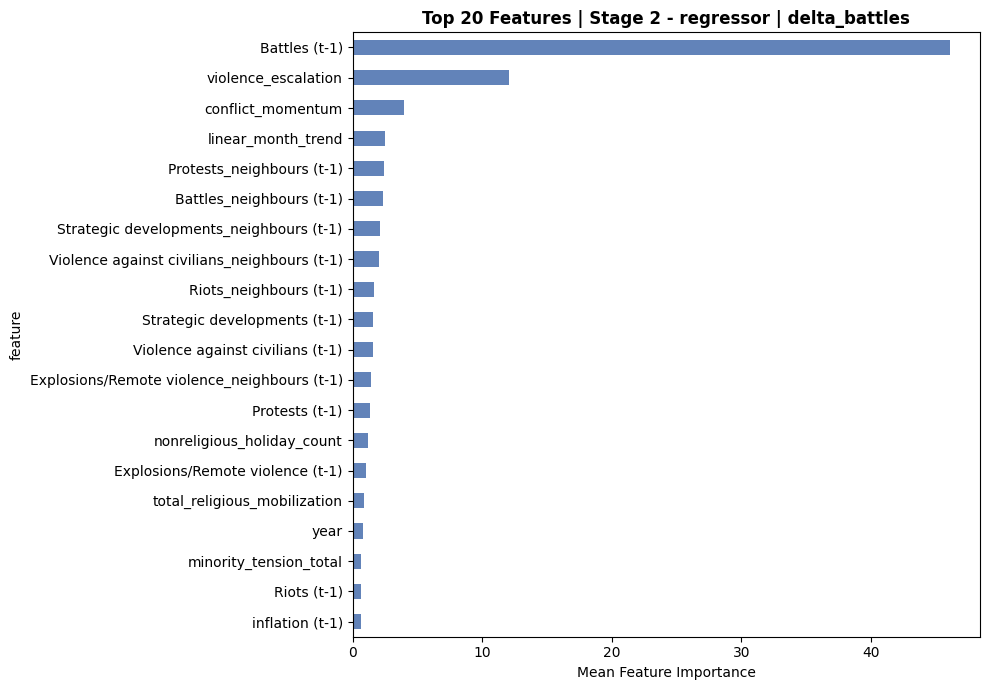

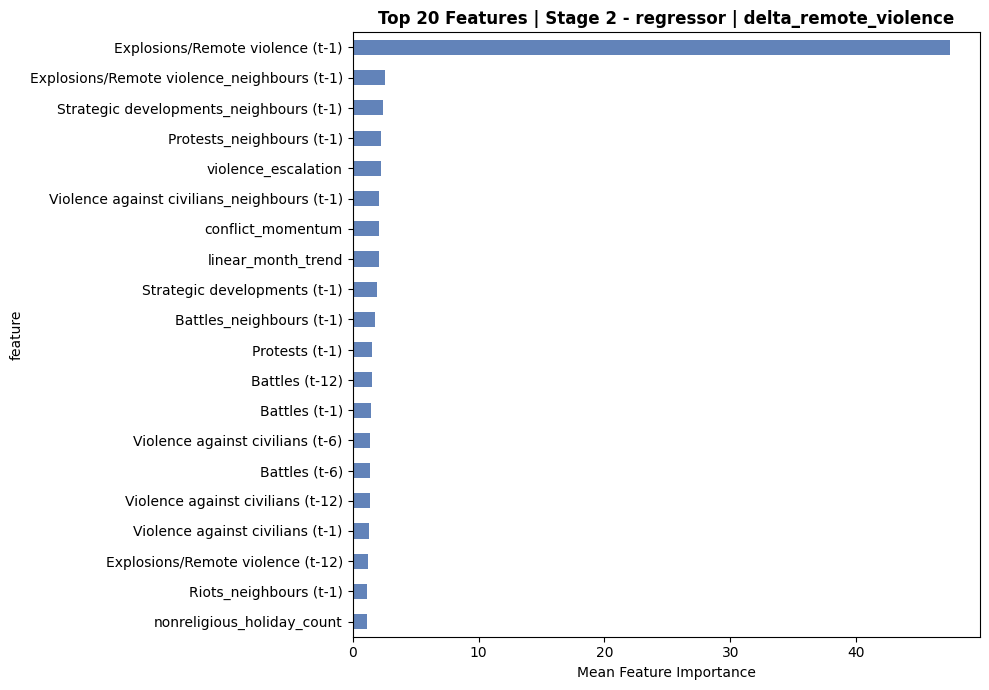

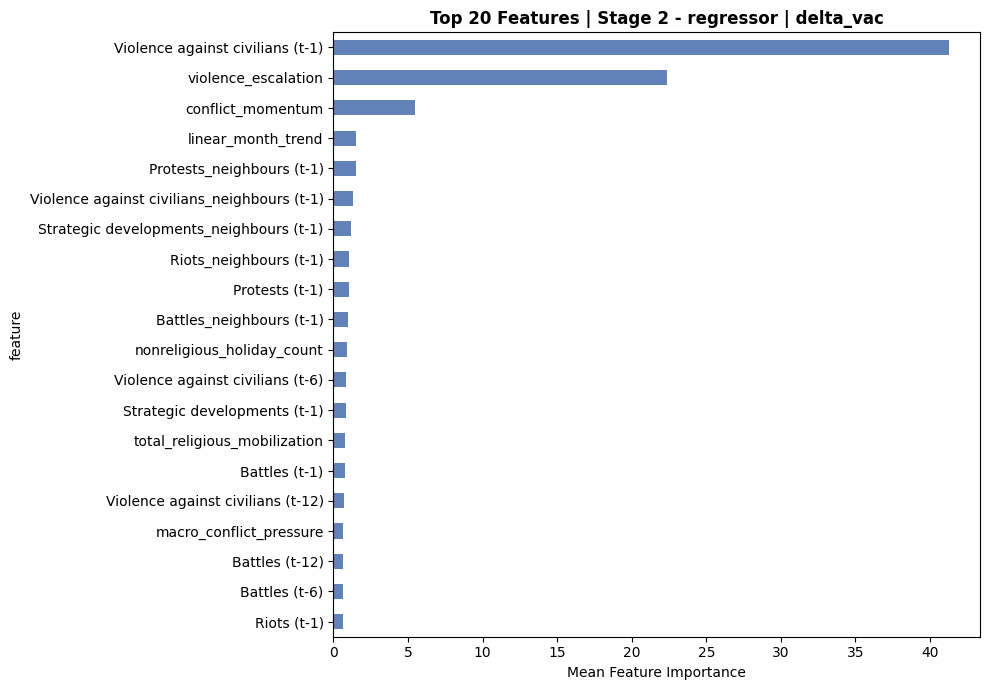

In [29]:
# Top 20 features per stage per target
import matplotlib.pyplot as plt

TOP_N = 20

for stage in ['Stage 1 - classifier', 'Stage 2 - regressor']:
    for target in DELTA_TARGETS:
        fi_stage = full_fi_df[
            (full_fi_df['stage'] == stage) &
            (full_fi_df['target'] == target)
        ]

        if fi_stage.empty:
            continue

        top_features = (
            fi_stage.groupby('feature')['importance']
            .mean()
            .sort_values(ascending=False)
            .head(TOP_N)
        )

        plt.figure(figsize=(10, 7))
        top_features.sort_values().plot(kind='barh', color='#4C72B0', alpha=0.88)
        plt.title(f'Top {TOP_N} Features | {stage} | {target}', fontweight='bold')
        plt.xlabel('Mean Feature Importance')
        plt.tight_layout()
        plt.show()